# 19 — Streaming LiDAR or fusion BEV detections

This notebook replays the synchronized KITTI Raw drive `2011_09_26_drive_0011_sync` using either the LiDAR-only or LiDAR–camera fusion detector. Select the model with `INPUT_MODE` in the configuration cell.

```text
synchronized Raw frame → selected BEV representation → selected detector → live dashboard
```

In [7]:
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, clear_output, display

CURRENT_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIRECTORY if (CURRENT_DIRECTORY / "src").is_dir() else CURRENT_DIRECTORY.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_raw_sequence import KittiRawSequence
from src.inference.pipeline import load_detector_checkpoint
from src.inference.streaming import stream_dataset, summarize_stream_timings

## Configuration

Start with 50 frames. Increase `FRAME_LIMIT` after confirming playback works. `SAVE_VIDEO=True` writes an MP4 that can be replayed smoothly after inference. The live notebook display itself adds substantial latency, so model FPS and end-to-end FPS are reported separately.

In [8]:
# Change only this flag to switch the detector.
INPUT_MODE = "fusion"  # Allowed values: "lidar" or "fusion"

CHECKPOINTS = {
    "lidar": PROJECT_ROOT / "outputs" / "bev_detector_multiscale_full.pth",
    "fusion": PROJECT_ROOT / "outputs" / "bev_detector_fusion_full_seed42.pth",
}
if INPUT_MODE not in CHECKPOINTS:
    raise ValueError("INPUT_MODE must be 'lidar' or 'fusion'")
CHECKPOINT_PATH = CHECKPOINTS[INPUT_MODE]

RAW_DATE_ROOT = PROJECT_ROOT / "data" / "KITTI" / "2011_09_26"
RAW_DRIVE = "2011_09_26_drive_0011_sync"
OUTPUT_VIDEO = PROJECT_ROOT / "outputs" / f"kitti_{INPUT_MODE}_bev_stream.mp4"

START_INDEX = 0
FRAME_LIMIT = 50
SCORE_THRESHOLD = 0.30
TOP_K = 50
MIN_CENTER_DISTANCE = 1.5
DISPLAY_EVERY = 1
SAVE_VIDEO = False
OUTPUT_WIDTH = 1200
OUTPUT_HEIGHT = 360
VIDEO_FPS = 10.0

In [9]:
model, checkpoint, device = load_detector_checkpoint(
    CHECKPOINT_PATH,
    device="auto",
)
expected_channels = {"lidar": 3, "fusion": 7}[INPUT_MODE]
if checkpoint["config"]["input_mode"] != INPUT_MODE:
    raise ValueError("The selected checkpoint does not match INPUT_MODE.")
if checkpoint["config"]["input_channels"] != expected_channels:
    raise ValueError("The selected checkpoint has an unexpected input-channel count.")

dataset = KittiRawSequence(
    date_root=RAW_DATE_ROOT,
    drive=RAW_DRIVE,
)
stop_index = min(len(dataset), START_INDEX + FRAME_LIMIT)
stream_indices = list(range(START_INDEX, stop_index))
if not stream_indices:
    raise ValueError("The selected stream contains no frames.")

print("Input mode:", INPUT_MODE)
print("Input channels:", expected_channels)
print("Device:", device)
print("Raw sequence frames:", len(dataset))
print("Frames selected:", len(stream_indices))
print("Checkpoint:", CHECKPOINT_PATH)

Device: cuda
Dataset frames: 7518
Frames selected: 50
Checkpoint: /home/rahul/projects/kitti-lidar-detector/outputs/bev_detector_fusion_full_seed42.pth


## Conventional forward-up rendering

The shared streaming module displays the ego vehicle at the bottom, forward motion upward, vehicle-left on the left, and vehicle-right on the right. Orange rectangles show detected boxes and red arrows show their predicted heading. The same coordinate transform is applied to the density image, corners, centers, labels, and arrows.

In [10]:
def notebook_frame_callback(dashboard, frame_record, total_frames):
    success, encoded = cv2.imencode(".jpg", dashboard)
    if success:
        clear_output(wait=True)
        display(Image(data=encoded.tobytes()))
        print(
            f"Processed {frame_record['position'] + 1}/{total_frames} frames | "
            f"detections={len(frame_record['detections'])}"
        )

## Run the stream

CUDA operations are synchronized around network timing because GPU execution is asynchronous. Press the notebook stop button to interrupt a long run. The MP4 writer is always released through `finally`, even if execution is interrupted.

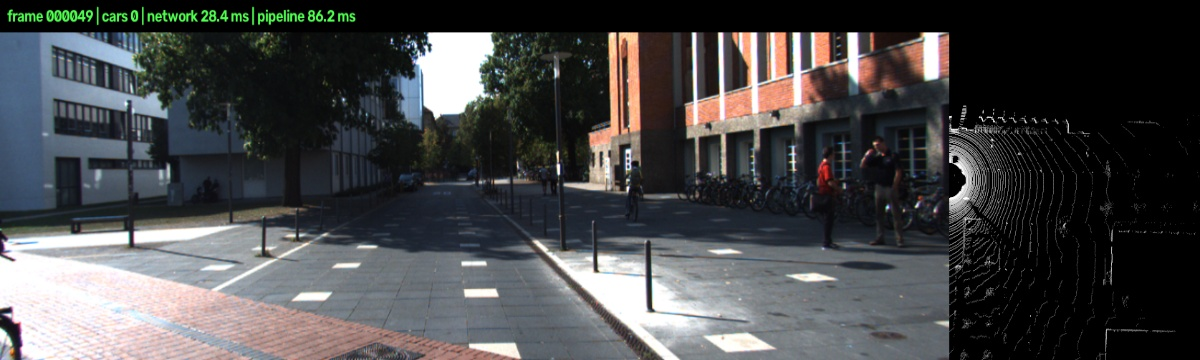

Processed 50/50 frames
Stream complete.


In [11]:
output_video = OUTPUT_VIDEO if SAVE_VIDEO else None

stream_result = stream_dataset(
    model=model,
    dataset=dataset,
    indices=stream_indices,
    input_mode=INPUT_MODE,
    device=device,
    score_threshold=SCORE_THRESHOLD,
    top_k=TOP_K,
    min_center_distance=MIN_CENTER_DISTANCE,
    output_video=output_video,
    video_fps=VIDEO_FPS,
    output_size=(OUTPUT_WIDTH, OUTPUT_HEIGHT),
    display_every=DISPLAY_EVERY,
    frame_callback=notebook_frame_callback,
    draw_heading=True,
)

print("Stream complete.")
if output_video is not None:
    print("Saved video:", output_video)

## Performance summary

`Network FPS` measures only the CNN forward pass. `Pipeline FPS` includes loading, camera-to-LiDAR painting, BEV creation, inference, decoding, and rendering, but excludes most notebook display overhead. For a real application, the end-to-end pipeline number matters more.

Preprocessing : mean   35.69 ms | median   33.31 ms | effective  28.02 FPS
Network       : mean   30.53 ms | median   26.78 ms | effective  32.76 FPS
Decoding      : mean    7.60 ms | median    6.42 ms | effective 131.61 FPS
Rendering     : mean    3.53 ms | median    2.91 ms | effective 283.15 FPS
Pipeline      : mean   96.35 ms | median   87.59 ms | effective  10.38 FPS


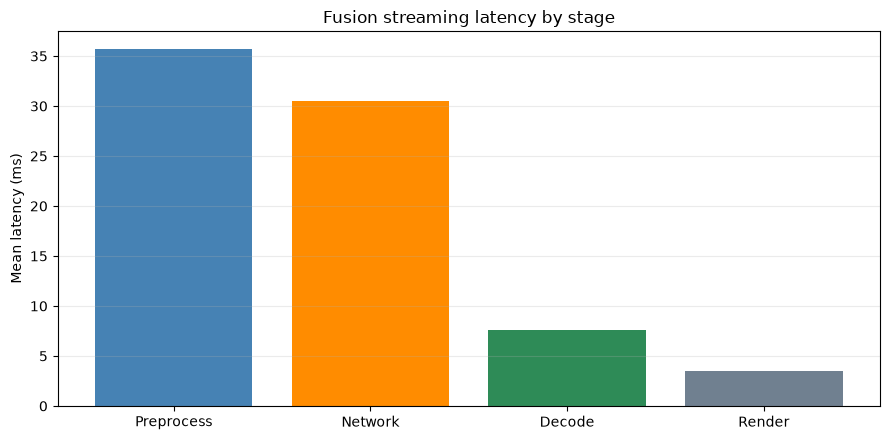

In [12]:
timing_summary = summarize_stream_timings(stream_result)

for name, statistics in timing_summary.items():
    print(
        f"{name:14s}: mean {1000 * statistics['mean_seconds']:7.2f} ms | "
        f"median {1000 * statistics['median_seconds']:7.2f} ms | "
        f"effective {statistics['fps']:6.2f} FPS"
    )

labels = ["Preprocess", "Network", "Decode", "Render"]
keys = ["preprocessing", "network", "decoding", "rendering"]
means = [1000 * timing_summary[key]["mean_seconds"] for key in keys]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, means, color=["steelblue", "darkorange", "seagreen", "slategray"])
ax.set_ylabel("Mean latency (ms)")
ax.set_title("Fusion streaming latency by stage")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Interpretation and next step

A successful run proves that your complete fusion pipeline can operate repeatedly without reloading the model. It does not yet prove real-time operation or temporal stability, because KITTI object-detection frames are not sequential. Next, reuse these helpers with a KITTI Tracking sequence, preserve timestamp order, and measure box flicker and missed detections across adjacent frames.